In [1]:
from glob import glob
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import os
import pandas as pd 
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import sys

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
results = "../evaluation_results/1_4_edist/*/*.csv"

In [3]:
datasets = [f"mcfarland_{i}" for i in range(1, 6)] + ["bhattacherjee_Astro", "bhattacherjee_Endo", "bhattacherjee_Excitatory", "norman", "schiebinger"]

In [4]:
csvs = glob(results) 

In [5]:
dfs = list()
runtime_memory = list()
for dataset in datasets:
    dataset_df_dict = {csv.split("/")[3]: pd.read_csv(csv, index_col="testgroup") for csv in csvs if dataset in csv}
    for method in dataset_df_dict:
        keep = [c for c in dataset_df_dict[method].columns if "time" in c]
        dataset_df_dict[method] = dataset_df_dict[method][keep]
        dataset_df_dict[method].columns = [f"{method}_{c}" for c in dataset_df_dict[method].columns]
    dataset_df = pd.concat(list(dataset_df_dict.values()), axis=1)
    dataset_df["dataset"] = dataset
    dfs.append(dataset_df)
result = pd.concat(dfs)

In [13]:
result = result.fillna(1000000)

In [14]:
xm_time = dict()
edist_time_with_subsampling_10k = dict()
edist_time_with_subsampling_20k = dict()
edist_time_no_subsampling_10k = dict()
edist_time_no_subsampling_20k = dict()

for (dataset, df) in result.groupby("dataset"):
    xm_time[dataset] = df["scxmatch_time_test"].sum()
    edist_time_with_subsampling_10k[dataset] = float(df["with_subsampling_10k_time_pca"].iloc[0]) + float(df["with_subsampling_10k_time_edist_test"].iloc[0])
    edist_time_with_subsampling_20k[dataset] = float(df["with_subsampling_20k_time_pca"].iloc[0]) + float(df["with_subsampling_20k_time_edist_test"].iloc[0])
    edist_time_no_subsampling_10k[dataset] = float(df["without_subsampling_10k_time_pca"].iloc[0]) + float(df["without_subsampling_10k_time_edist_test"].iloc[0])
    edist_time_no_subsampling_20k[dataset] = float(df["without_subsampling_20k_time_pca"].iloc[0]) + float(df["without_subsampling_20k_time_edist_test"].iloc[0])

In [15]:
times = pd.DataFrame([xm_time, edist_time_with_subsampling_10k, edist_time_with_subsampling_20k, edist_time_no_subsampling_10k, edist_time_no_subsampling_20k], index=["scXMatch", "E-distance with subsampling, N=10k", "E-distance with subsampling, N=20k", "E-distance no subsampling, N=10k", "E-distance no subsampling, N=20k",]).T.reset_index(names="dataset")

In [9]:
melted = pd.melt(times, id_vars=["dataset"], var_name="method", value_name="runtime")

In [10]:
melted["runtime [min]"] = melted["runtime"] / 60

In [11]:
palette = sns.color_palette("viridis", 4) + sns.color_palette("magma", 1)
palette_dict = {           
    "E-distance with subsampling, N=20k": palette[0],
    "E-distance with subsampling, N=10k": palette[1],
    "E-distance no subsampling, N=10k": palette[2],
    "E-distance no subsampling, N=20k": palette[3],
    "scXMatch": palette[4],
}

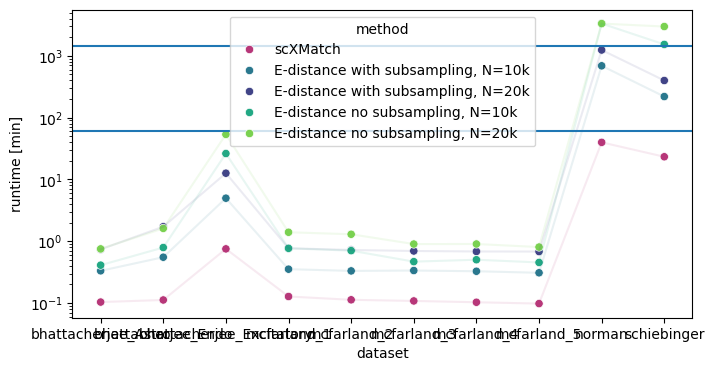

In [12]:
plt.figure(figsize=(8, 4))
sns.scatterplot(melted, hue="method", y="runtime [min]", x="dataset", palette=palette_dict)
sns.lineplot(melted, hue="method", y="runtime [min]", x="dataset", alpha=0.1, legend=False, palette=palette_dict)
plt.yscale("log")
plt.axhline(24*60)
plt.axhline(60)
plt.savefig("../plots/supp/runtimes_edist_configurations.svg")